In [60]:
import os, zipfile, random, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from collections import Counter

In [ ]:
# SMART EXTRACTION + FOLDER DETECTION FIX

import zipfile, shutil, os
from pathlib import Path

# Define paths
DATA_ROOT = Path("./data_extracted_fixed")
TRAIN_ZIP = "D:/Projects/Project-6-Brain Tumor MRI Image Classification/train-20251028T041953Z-1-001.zip"
VALID_ZIP = "D:/Projects/Project-6-Brain Tumor MRI Image Classification/valid-20251028T042215Z-1-001.zip"
TEST_ZIP  = "D:/Projects\Project-6-Brain Tumor MRI Image Classification/test-20251028T041929Z-1-001.zip"

# Clean old extraction if exists
if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

def smart_extract(zip_path, target_dir):
    """Extract zip and automatically detect the actual 'train/valid/test' folder level."""
    print(f"Extracting {zip_path} ...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(target_dir)
    print(f"Extracted to {target_dir}")
    
    # Find the real dataset folder (contains class subfolders)
    # e.g., /data/train/train/...  or /data/train/...
    candidates = list(Path(target_dir).rglob("train"))
    if not candidates:
        candidates = list(Path(target_dir).rglob("Train"))
    if candidates:
        print(f"Found train folder candidate: {candidates[0]}")
    return target_dir

# Extract all datasets
smart_extract(TRAIN_ZIP, DATA_ROOT / "train")
smart_extract(VALID_ZIP, DATA_ROOT / "valid")
smart_extract(TEST_ZIP,  DATA_ROOT / "test")

# Detect the deepest actual directories that contain class folders
def find_actual_dataset_dir(base_dir):
    base_dir = Path(base_dir)
    subdirs = [p for p in base_dir.rglob("*") if p.is_dir() and any(f.suffix.lower() in ['.jpg', '.jpeg', '.png'] for f in p.glob("*"))]
    if subdirs:
        # Return parent folder containing class folders
        parents = {p.parent for p in subdirs}
        best = min(parents, key=lambda p: len(p.parts))
        print(f"✅ Found valid dataset directory: {best}")
        return best
    else:
        print(f"⚠️ No images found under {base_dir}, check your zip structure.")
        return base_dir

TRAIN_DIR = find_actual_dataset_dir(DATA_ROOT / "train")
VALID_DIR = find_actual_dataset_dir(DATA_ROOT / "valid")
TEST_DIR  = find_actual_dataset_dir(DATA_ROOT / "test")

print(f"\nFinal dataset directories:")
print(f"Train dir: {TRAIN_DIR}")
print(f"Valid dir: {VALID_DIR}")
print(f"Test dir:  {TEST_DIR}")

# Quick verification
for root, dirs, files in os.walk(TRAIN_DIR):
    print(f"\nSample structure check:\n{root} -> {len(dirs)} class folders")
    print("Classes:", dirs)
    break


<>:10: SyntaxWarning: invalid escape sequence '\P'
<>:10: SyntaxWarning: invalid escape sequence '\P'
C:\Users\User\AppData\Local\Temp\ipykernel_12164\1109926884.py:10: SyntaxWarning: invalid escape sequence '\P'
  TEST_ZIP  = "D:/Projects\Project-6-Brain Tumor MRI Image Classification/test-20251028T041929Z-1-001.zip"


Extracting D:/Projects/Project-6-Brain Tumor MRI Image Classification/train-20251028T041953Z-1-001.zip ...
Extracted to data_extracted_fixed\train
Found train folder candidate: data_extracted_fixed\train\train
Extracting D:/Projects/Project-6-Brain Tumor MRI Image Classification/valid-20251028T042215Z-1-001.zip ...
Extracted to data_extracted_fixed\valid
Extracting D:/Projects\Project-6-Brain Tumor MRI Image Classification/test-20251028T041929Z-1-001.zip ...
Extracted to data_extracted_fixed\test
✅ Found valid dataset directory: data_extracted_fixed\train\train
✅ Found valid dataset directory: data_extracted_fixed\valid\valid
✅ Found valid dataset directory: data_extracted_fixed\test\test

Final dataset directories:
Train dir: data_extracted_fixed\train\train
Valid dir: data_extracted_fixed\valid\valid
Test dir:  data_extracted_fixed\test\test

Sample structure check:
data_extracted_fixed\train\train -> 4 class folders
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [62]:
# 1) CONFIG

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_ROOT = Path("data_extracted_fixed")   # already extracted (from your previous step)
TRAIN_DIR = DATA_ROOT / "train" / "train"
VALID_DIR = DATA_ROOT / "valid" / "valid"
TEST_DIR  = DATA_ROOT / "test" / "test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
OUTPUT_DIR = Path("models_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [63]:
# 2️) DATA PREPROCESSING (Fixed for RGB inputs)

print("✅ Preparing datasets...")

def create_dataset(directory, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        batch_size=batch_size,
        image_size=img_size,
        shuffle=shuffle,
        seed=SEED,
        color_mode="rgb"   # 👈 Force 3-channel RGB to avoid grayscale mismatch
    )
    return ds

train_ds = create_dataset(TRAIN_DIR)
val_ds   = create_dataset(VALID_DIR, shuffle=False)
test_ds  = create_dataset(TEST_DIR, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# ✅ Sanity check: verify image shape
for images, labels in train_ds.take(1):
    print(f"Sample image batch shape: {images.shape}")
    print(f"Sample label batch shape: {labels.shape}")

# Normalize pixel values to [0–1]
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for better performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

✅ Preparing datasets...
Found 1695 files belonging to 4 classes.
Found 502 files belonging to 4 classes.
Found 246 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Sample image batch shape: (32, 224, 224, 3)
Sample label batch shape: (32,)


In [64]:
# 3️) DATA AUGMENTATION

print("✅ Setting up augmentation...")
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

✅ Setting up augmentation...


In [65]:
# 4️) MODEL BUILDING (Fixed & Verified)

print("✅ Building models...")

# ---- Custom CNN ----
def build_custom_cnn(input_shape=(224,224,3), num_classes=4):
    model = models.Sequential([
        data_augmentation,
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

custom_cnn = build_custom_cnn((224,224,3), num_classes)
custom_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
custom_cnn.summary()

# ---- Transfer Learning Models ----
def build_transfer_model(base_model, num_classes=4):
    base_model.trainable = False
    inputs = layers.Input(shape=(224,224,3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model

transfer_models = {
    "ResNet50": build_transfer_model(applications.ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3)), num_classes),
    "MobileNetV2": build_transfer_model(applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3)), num_classes),
    "InceptionV3": build_transfer_model(applications.InceptionV3(weights="imagenet", include_top=False, input_shape=(224,224,3)), num_classes),
}

✅ Building models...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

✅ Training models...

Training CustomCNN ...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.4496 - loss: 1.5513 

53/53 ━━━━━━━━━━━━━━━━━━━━ 936s 16s/step - accuracy: 0.5204 - loss: 1.3537 - val_accuracy: 0.3207 - val_loss: 1.3713
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 761s 14s/step - accuracy: 0.6100 - loss: 1.1174 - val_accuracy: 0.3446 - val_loss: 1.4984
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 735s 14s/step - accuracy: 0.6083 - loss: 1.1345 - val_accuracy: 0.3307 - val_loss: 1.7259
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 748s 14s/step - accuracy: 0.6324 - loss: 1.0481 - val_accuracy: 0.4283 - val_loss: 1.9310
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 941s 17s/step - accuracy: 0.6460 - loss: 1.0353 - val_accuracy: 0.4841 - val_loss: 2.0557


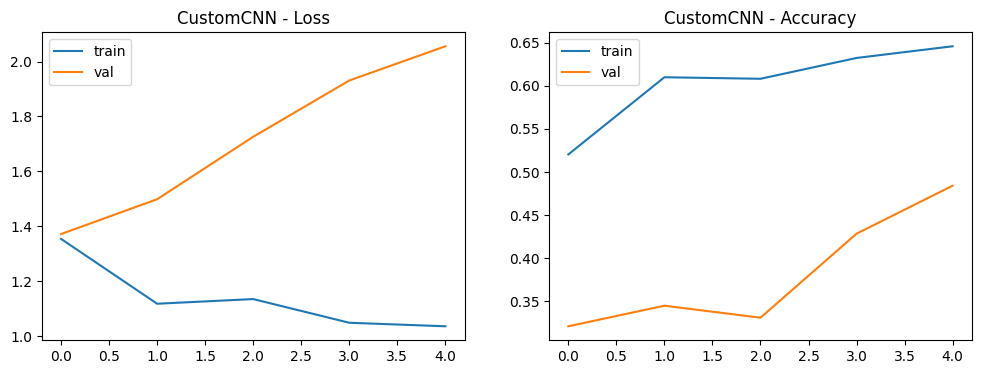


Training ResNet50 ...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.2751 - loss: 1.6189 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1661s 30s/step - accuracy: 0.2767 - loss: 1.5752 - val_accuracy: 0.3207 - val_loss: 1.3859
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.2994 - loss: 1.5155 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1381s 25s/step - accuracy: 0.2873 - loss: 1.5248 - val_accuracy: 0.3207 - val_loss: 1.3705
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.2837 - loss: 1.4949 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1295s 25s/step - accuracy: 0.2814 - loss: 1.4995 - val_accuracy: 0.3207 - val_loss: 1.3580
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.2810 - loss: 1.5082 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1455s 27s/step - accuracy: 0.2897 - loss: 1.4961 - val_accuracy: 0.3287 - val_loss: 1.3453
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.2889 - loss: 1.4961 

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 1386s 26s/step - accuracy: 0.3493 - loss: 1.3671 - val_accuracy: 0.4442 - val_loss: 1.2726
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.3470 - loss: 1.3418 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1345s 25s/step - accuracy: 0.3434 - loss: 1.3603 - val_accuracy: 0.4363 - val_loss: 1.2636
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.3480 - loss: 1.3338 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1342s 25s/step - accuracy: 0.3581 - loss: 1.3331 - val_accuracy: 0.4323 - val_loss: 1.2536
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.3619 - loss: 1.3571 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1325s 25s/step - accuracy: 0.3746 - loss: 1.3426 - val_accuracy: 0.4980 - val_loss: 1.2482
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.3765 - loss: 1.3196 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1428s 27s/step - accuracy: 0.3847 - loss: 1.3124 - val_accuracy: 0.4323 - val_loss: 1.2372


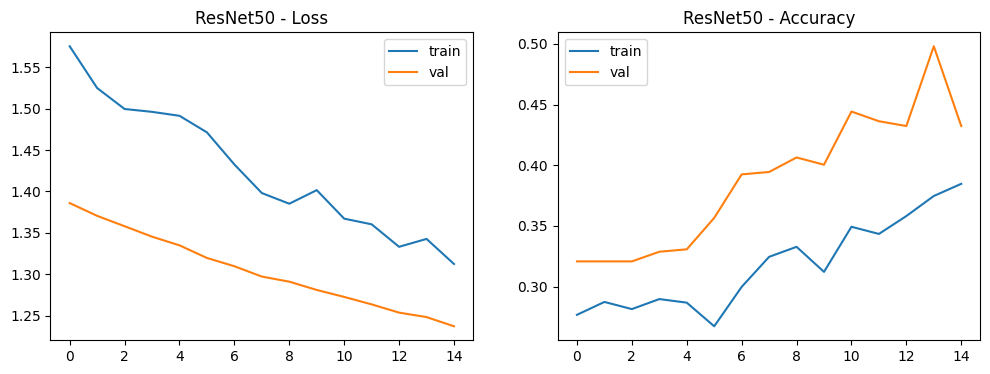


Training MobileNetV2 ...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2823 - loss: 1.5891

53/53 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - accuracy: 0.3268 - loss: 1.5082 - val_accuracy: 0.4163 - val_loss: 1.3112
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4482 - loss: 1.2919

53/53 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.4708 - loss: 1.2397 - val_accuracy: 0.5020 - val_loss: 1.1539
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5119 - loss: 1.1633

53/53 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.5304 - loss: 1.1193 - val_accuracy: 0.5857 - val_loss: 1.0362
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5970 - loss: 1.0080

53/53 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.6018 - loss: 0.9933 - val_accuracy: 0.6175 - val_loss: 0.9631
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6136 - loss: 0.9332

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 208s 3s/step - accuracy: 0.6885 - loss: 0.7616 - val_accuracy: 0.6833 - val_loss: 0.7899
Epoch 10/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7136 - loss: 0.7275

53/53 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step - accuracy: 0.7121 - loss: 0.7315 - val_accuracy: 0.6773 - val_loss: 0.7780
Epoch 11/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7346 - loss: 0.6931

53/53 ━━━━━━━━━━━━━━━━━━━━ 220s 4s/step - accuracy: 0.7345 - loss: 0.7020 - val_accuracy: 0.6833 - val_loss: 0.7634
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7127 - loss: 0.7107

53/53 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.7268 - loss: 0.7014 - val_accuracy: 0.7012 - val_loss: 0.7340
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 164s 3s/step - accuracy: 0.7316 - loss: 0.6532 - val_accuracy: 0.7032 - val_loss: 0.7403
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.7499 - loss: 0.6543 - val_accuracy: 0.7012 - val_loss: 0.7345
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7600 - loss: 0.6274

53/53 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.7628 - loss: 0.6249 - val_accuracy: 0.7052 - val_loss: 0.7148


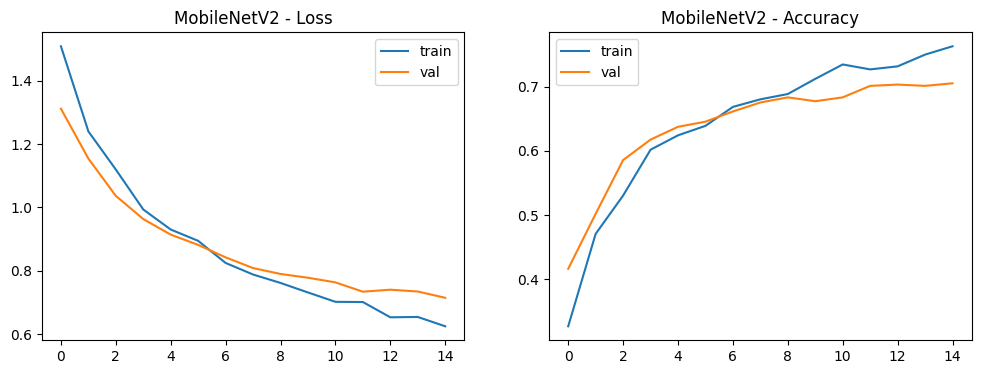


Training InceptionV3 ...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.2985 - loss: 1.5696 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1046s 19s/step - accuracy: 0.3316 - loss: 1.4975 - val_accuracy: 0.4303 - val_loss: 1.2777
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.4158 - loss: 1.3126 

53/53 ━━━━━━━━━━━━━━━━━━━━ 959s 18s/step - accuracy: 0.4584 - loss: 1.2451 - val_accuracy: 0.5657 - val_loss: 1.0931
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.5267 - loss: 1.1517 

53/53 ━━━━━━━━━━━━━━━━━━━━ 1043s 19s/step - accuracy: 0.5504 - loss: 1.1109 - val_accuracy: 0.6056 - val_loss: 1.0018
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.6024 - loss: 1.0075 

53/53 ━━━━━━━━━━━━━━━━━━━━ 974s 18s/step - accuracy: 0.6218 - loss: 0.9830 - val_accuracy: 0.6335 - val_loss: 0.9303
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.6021 - loss: 0.9990 

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 916s 17s/step - accuracy: 0.7062 - loss: 0.7515 - val_accuracy: 0.7092 - val_loss: 0.7778
Epoch 11/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.6866 - loss: 0.7317 

53/53 ━━━━━━━━━━━━━━━━━━━━ 935s 17s/step - accuracy: 0.6962 - loss: 0.7254 - val_accuracy: 0.7012 - val_loss: 0.7679
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7116 - loss: 0.7208 

53/53 ━━━━━━━━━━━━━━━━━━━━ 924s 18s/step - accuracy: 0.7180 - loss: 0.7062 - val_accuracy: 0.7171 - val_loss: 0.7269
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.7284 - loss: 0.6984 

53/53 ━━━━━━━━━━━━━━━━━━━━ 931s 18s/step - accuracy: 0.7103 - loss: 0.7198 - val_accuracy: 0.7171 - val_loss: 0.7221
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 922s 17s/step - accuracy: 0.7327 - loss: 0.6937 - val_accuracy: 0.6972 - val_loss: 0.7509
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7555 - loss: 0.6642 

53/53 ━━━━━━━━━━━━━━━━━━━━ 913s 17s/step - accuracy: 0.7481 - loss: 0.6828 - val_accuracy: 0.7371 - val_loss: 0.6849


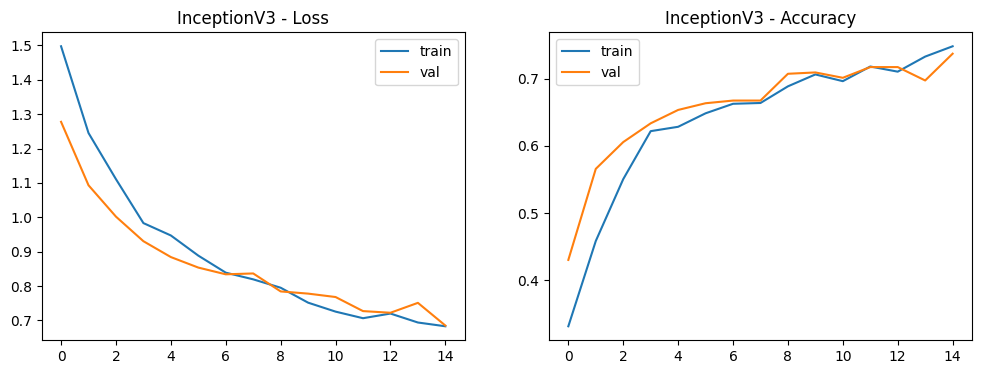

In [66]:
# 5️) MODEL TRAINING

print("✅ Training models...")
results = []

def train_model(model, name):
    print(f"\nTraining {name} ...")
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{OUTPUT_DIR}/{name}_best.h5", save_best_only=True)
    ]
    model.compile(optimizer=optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb)
    # Plot history
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{name} - Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{name} - Accuracy'); plt.legend()
    plt.show()
    return model, history

# Train Custom CNN
custom_cnn, history_cnn = train_model(custom_cnn, "CustomCNN")

# Train Transfer Models
for name, model in transfer_models.items():
    model, hist = train_model(model, name)
    transfer_models[name] = model

✅ Evaluating models...


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag


📊 CustomCNN Results:
Accuracy=0.3293  Precision=0.1322  Recall=0.3293  F1=0.1715
              precision    recall  f1-score   support

      glioma       0.34      1.00      0.51        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.10      0.02      0.03        54

    accuracy                           0.33       246
   macro avg       0.11      0.25      0.13       246
weighted avg       0.13      0.33      0.17       246



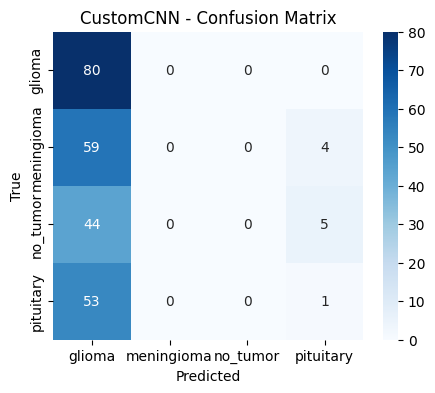


📊 ResNet50 Results:
Accuracy=0.4350  Precision=0.5093  Recall=0.4350  F1=0.3164
              precision    recall  f1-score   support

      glioma       0.38      1.00      0.56        80
  meningioma       0.50      0.02      0.03        63
    no_tumor       0.74      0.51      0.60        49
   pituitary       0.50      0.02      0.04        54

    accuracy                           0.43       246
   macro avg       0.53      0.39      0.31       246
weighted avg       0.51      0.43      0.32       246



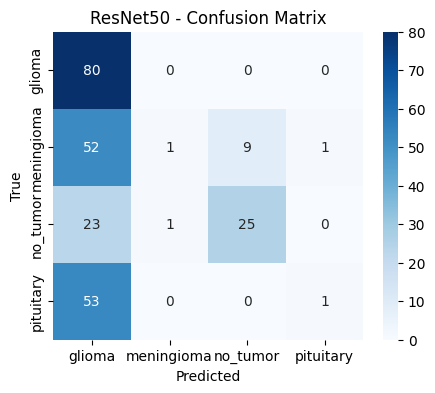


📊 MobileNetV2 Results:
Accuracy=0.6626  Precision=0.7351  Recall=0.6626  F1=0.6637
              precision    recall  f1-score   support

      glioma       0.89      0.64      0.74        80
  meningioma       0.68      0.41      0.51        63
    no_tumor       0.83      0.69      0.76        49
   pituitary       0.47      0.96      0.63        54

    accuracy                           0.66       246
   macro avg       0.72      0.68      0.66       246
weighted avg       0.74      0.66      0.66       246



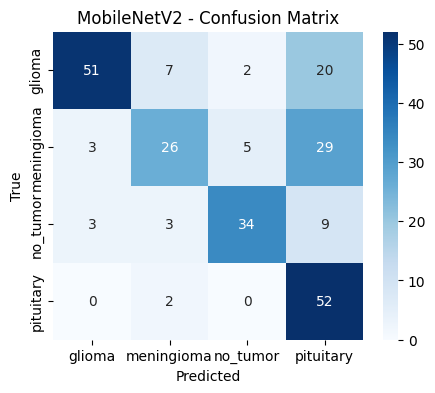


📊 InceptionV3 Results:
Accuracy=0.7073  Precision=0.7241  Recall=0.7073  F1=0.7035
              precision    recall  f1-score   support

      glioma       0.82      0.75      0.78        80
  meningioma       0.61      0.48      0.54        63
    no_tumor       0.85      0.69      0.76        49
   pituitary       0.60      0.93      0.72        54

    accuracy                           0.71       246
   macro avg       0.72      0.71      0.70       246
weighted avg       0.72      0.71      0.70       246



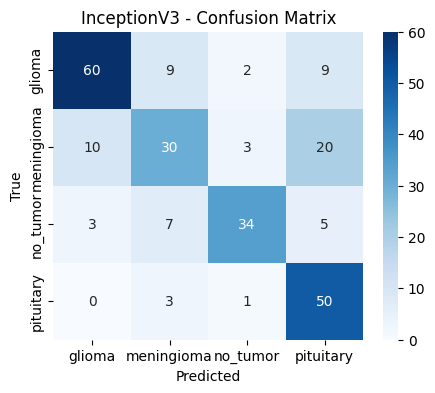

In [67]:
# 6️) MODEL EVALUATION

print("✅ Evaluating models...")

def evaluate_model(model, name):
    y_true, y_pred = [], []
    for imgs, labels in test_ds:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f"\n📊 {name} Results:")
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# Evaluate all models
results.append(evaluate_model(custom_cnn, "CustomCNN"))
for name, model in transfer_models.items():
    results.append(evaluate_model(model, name))


✅ Model Comparison Summary:
         model  accuracy  precision    recall        f1
3  InceptionV3  0.707317   0.724056  0.707317  0.703511
2  MobileNetV2  0.662602   0.735145  0.662602  0.663674
1     ResNet50  0.434959   0.509344  0.434959  0.316380
0    CustomCNN  0.329268   0.132190  0.329268  0.171520


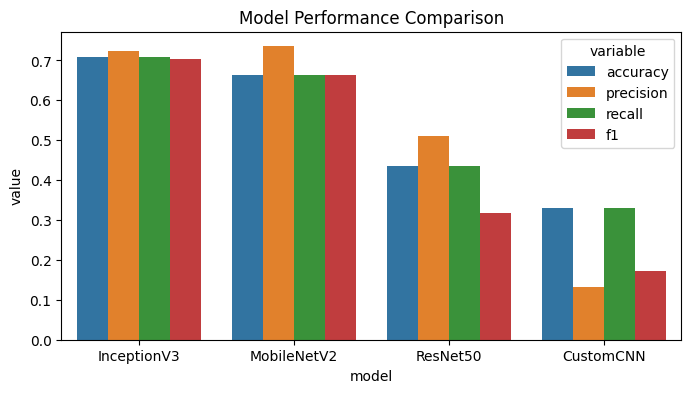


🏆 Best Performing Model: InceptionV3


In [68]:
# 7️) MODEL COMPARISON

df = pd.DataFrame(results).sort_values("f1", ascending=False)
print("\n✅ Model Comparison Summary:")
print(df)

plt.figure(figsize=(8,4))
sns.barplot(data=df.melt(id_vars='model', value_vars=['accuracy','precision','recall','f1']),
            x='model', y='value', hue='variable')
plt.title("Model Performance Comparison")
plt.show()

best_model_name = df.iloc[0]["model"]
print(f"\n🏆 Best Performing Model: {best_model_name}")

In [69]:
import pickle
from tensorflow.keras.models import load_model

# save to h5
best_model_path = f"models_outputs/{best_model_name}_best.h5"
best_model = load_model(best_model_path)

# Save to pickle
pickle_path = f"models_outputs/{best_model_name}_best.pkl"
with open(pickle_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"✅ Saved best model as: {pickle_path}")

✅ Saved best model as: models_outputs/InceptionV3_best.pkl
